# **Directed percolation in Rust-Python**

First stab at implementing DP in Rust with a Python convenience wrapper.

**NOT YET RUNNING DP**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from typing import Any
from numpy.typing import NDArray
from dprs import sim

In [2]:
class Parameters:
    dim = sim.Dimension.D2
    processing = sim.Processing.Parallel
    n_x: int = 31 #10_000
    n_y: int = 21 #10_000
    n_z: int = 1
    edge_topology_x = (sim.Topology.Periodic, sim.Topology.Periodic)
    edge_topology_y = (sim.Topology.Pinned, sim.Topology.Pinned)
    edge_topology_z = (sim.Topology.Unspecified, sim.Topology.Unspecified)
    edge_values_x = (True, True)
    edge_values_y = (True, True)
    edge_values_z = (False, False)
    p: float = 0.5
    n_iterations: int = 100
    sample_rate: int = 10
    n_threads: int = 8
    serial_skip: int = 10
    do_buffering: bool = False
parameters = Parameters()

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [3]:
n_lattices: int
raw_lattices: list[list[bool]] 
(n_lattices, raw_lattices,)= sim.dp(parameters)
n_lattices


Dimension:   D2
Grid shape:  (31, 21, 1)
Topology x:  (Periodic, Periodic)
Topology y:  (Pinned, Pinned)
Topology z:  (Unspecified, Unspecified)
Edge x vals: (true, true)
Edge y vals: (true, true)
Edge z vals: (false, false)
Probability: 0.5
Iterations:  100
Sample rate: 10
Threads:     8
Serial skip: 10
Buffering:   false

Serial:   0.000s
Parallel: 0.000s
Chunked:  0.000s

Parallel speedup => 1.31x
Chunked speedup =>  1.38x



11

The function `sim.dp` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all them concatenated into one long 1d list.

Next, we convert this long list into a 2+1d numpy array, with the last index being the lattice slice number. Care must be taken to reshape by the grid dimensions in the correct order: the fastest index in the list is the x coordinate, etc., so the reshaping parameters need to be given in reverse order `(n_lattices, y, x)`.

In [4]:
raw_lattices: NDArray = np.array(raw_lattices, dtype=np.bool,) 
raw_lattices.shape

(11, 651)

In [5]:
lattices: NDArray = raw_lattices.reshape(
    n_lattices, 
    parameters.n_y, parameters.n_x,
    ).T
lattices.shape

(31, 21, 11)

Function to plot the lower-left portion of the lattice:

In [6]:
def image_lattice(
        lattices: NDArray, 
        p: Parameters,
        i_lattice: int=0, 
        x: int | None=None, 
        y: int | None=None,
    ) -> tuple[Figure, Any]:
    fig = plt.figure()
    color_map = ListedColormap(((0.8, 0.8, 0.8,), (0.7, 0, 0.7),))

    x = (lattices.shape[0] if x is None else x)
    y = (lattices.shape[1] if y is None else y)
    print(x,y)
    plt.imshow(
        lattices[0:x, 0:y, i_lattice,].T, 
        cmap=color_map, origin="lower",
    )
    color_bar = plt.colorbar(
        ticks=(0.25, 0.75,), 
        shrink=0.5*(p.n_y/p.n_x)**0.25, 
        aspect=15,
        label="cell state",
    )
    color_bar.set_ticklabels((0, 1,),)
    plt.xlabel(r"$x$")
    plt.ylabel(r"$y$")
    plt.grid(ls=":")
    return fig, plt

Show the initial lattice:

31 21


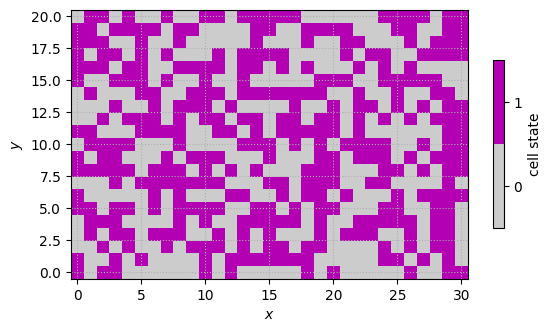

In [7]:
fig, plt = image_lattice(lattices, parameters, i_lattice=0,)
plt.show()

Show the final lattice:

31 21


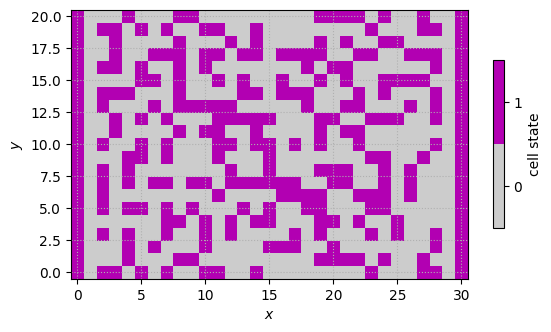

In [8]:
fig, plt = image_lattice(lattices, parameters, i_lattice=n_lattices-1,)
plt.show()